### Solve cavity flow governed by Navier-Stokes equation. using PINNs (Under simple setting)
Goal : using PINNs, predicts $(\psi, p)$ for the input $(x,y)$


Classical Navier-Stokes equation in 2D, Incompressible Navier-Stokes equations with constant viscosity (ignore external force)
\begin{align}
\boldsymbol{u}_t + (\boldsymbol{u} \cdot \nabla)\boldsymbol{u} + \nabla p/\rho = \nu \nabla^2 \boldsymbol{u}\\
\nabla \cdot \boldsymbol{u} = 0, \quad \text{where} \quad \boldsymbol{u}\equiv(u,v)
\end{align}
If steady state $u_t = 0$
\begin{align}
u_x + v_y &= 0\\
u u_x + v u_y + p_x/\rho - \nu(u_{xx} + u_{yy}) &= 0\\
u v_x + v v_y + p_y/\rho - \nu(v_{xx} + v_{yy}) &= 0\\
\end{align}
boundary condition

$\{x,y\} \in \{0,1\}\times\{0,1\}$

$(u,v)=(1,0)$ for $y=0$ and $(u,v)=(0,0)$ for other boundaries.

For simplify, define stream function $ (u, v) = (\frac{\partial \psi}{\partial y}, -\frac{\partial \psi}{\partial x})$

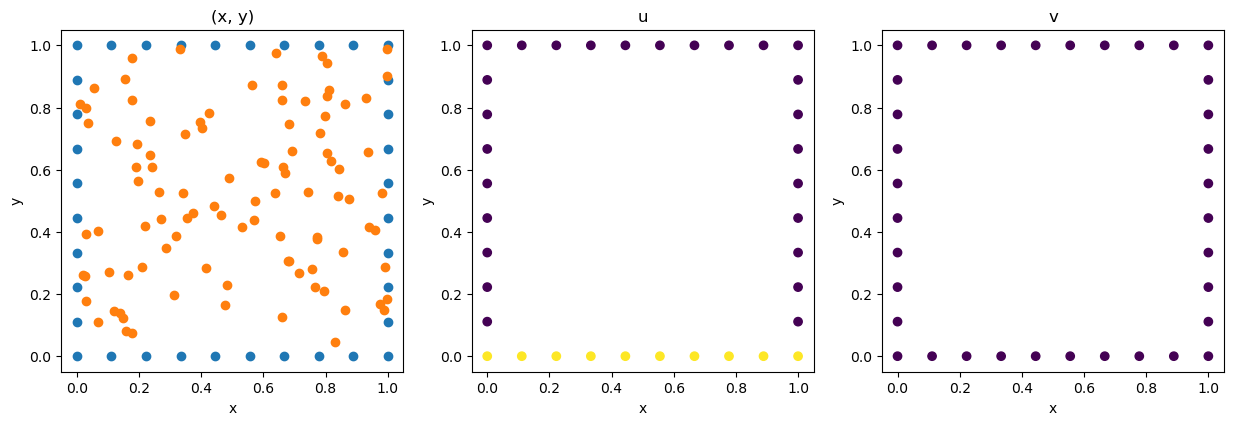

In [1]:
# YOUR CODE HERE (30pts)

# YOUR GENERATE TRAINING SET CODE HERE
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(1)


# Sampling domain points
N_bound = 10 # Number of smaple points at the boundary
N_bulk = 100 # Number of smaple points in the bulk
r_bound = torch.zeros((4*N_bound-4, 2))
x = torch.linspace(0, 1, N_bound)
y = torch.linspace(0, 1, N_bound)

# y = 0
for i in range(N_bound):
    r_bound[i, 0] = x[i]

# x = 1
for i in range(N_bound, 2*N_bound-2):
    r_bound[i, 0] = x[-1]
    r_bound[i, 1] = y[i+1-N_bound]

# y = 1
for i in range(2*N_bound-2, 3*N_bound-2):
    r_bound[i, 0] = x[i-(2*N_bound-2)]
    r_bound[i, 1] = y[-1]

# x = 0
for i in range(3*N_bound-2, 4*N_bound-4):
    r_bound[i:, 1] = y[i+1-(3*N_bound-2)]

r_bulk = torch.rand(N_bulk, 2)

# Boundary condition for u, v
u_bound = torch.zeros((4*N_bound-4))
u_bound[:N_bound] = 1.0
v_bound = torch.zeros((4*N_bound-4))

plt.figure(figsize=(15, 45))

plt.subplot(1, 3, 1)
plt.scatter(r_bound[:, 0], r_bound[:, 1])
plt.scatter(r_bulk[:, 0], r_bulk[:, 1])
plt.title('(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.subplot(1, 3, 2)
plt.scatter(r_bound[:, 0], r_bound[:, 1], c=u_bound)
plt.title('u')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.subplot(1, 3, 3)
plt.scatter(r_bound[:, 0], r_bound[:, 1], c=v_bound)
plt.title('v')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.show()

In [ ]:
# YOUR CODE HERE (30pts)

# YOUR NEURAL NETWORK DESIGN AND LOSS WITH RESIDUAL CODE HERE
PINN_net = nn.Sequential(
    # input: x, y
    # output: psi, p
    # If we consider psi, u_x+v_y = psi_xy - psi_yx = 0. Therefore, we don't need to consider Eq. (1)
    nn.Linear(2, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 2)
    )


def Residual(net, r_b, r, u_b, v_b, nu, r1=1e-1, r2=1e-3):
    '''
    net: Neural newtork
    r_b: (x, y) for boundary 
    r: (x, y) for bulk
    u_b: Boundary condition for u
    v_b: Boundary condition for v
    nu: PDE parameter

    Approach: Differentiate psi first, and fit boundary condition using u and v
    '''


    return 0.0

In [ ]:
# YOUR CODE HERE (30pts)

# YOUR TRAINING NEURAL NETWORK CODE HERE

In [ ]:
# VISUALIZATION (10pts)

# YOUR VISUALIZATION CODE HERE